# 203 · Anytime Valid Inference: Confidence Sequences

In traditional statistics, a **Confidence Interval (CI)** is only valid if you look at it *once* at a fixed sample size. If you monitor a CI as data arrives, the true parameter will eventually fall outside the interval more than $\alpha$% of the time.

**Confidence Sequences (CS)** are time-uniform confidence intervals. They are designed to contain the true parameter with at least $1-\alpha$ probability **at all times simultaneously**. 

This allows you to report a "live" interval that users can interpret safely as it shrinks.

## 1. Setup & CS Design

We use the `ConfidenceSequence_WaudbySmith2021` controller. Since Confidence Sequences are valid under any "peeking" schedule, we only need to specify our target $\alpha$ and a rough $N_{max}$ to optimize the interval's width.

In [1]:
import ibis
import numpy as np

import earlysign.schema.ES3.Base as ES3_BASE
from earlysign.controllers.ConfidenceSequence_WaudbySmith2021 import (
    BinomialConfidenceSequenceWaudbySmith2021Controller,
)
from earlysign.core.ledger import Ledger
from earlysign.schema.ES3.Binomial import BinomialArmData

ledger = Ledger(ibis.connect("duckdb://:memory:"), "cs_events")
ledger.ensure()

trial = BinomialConfidenceSequenceWaudbySmith2021Controller(ledger)
protocol = trial.design(
    arms=ES3_BASE.TwoArmComparison(
        control_arm_name="control", treatment_arm_name="treatment"
    ),
    alpha=0.05,
    variance=0.25,  # Max variance for Bernoulli
    max_n=5000,
    sides="two",
)
trial.set_protocol(protocol)

print("Confidence Sequence Design Initialized.")

Confidence Sequence Design Initialized.


### Design Operating Characteristics

We can simulate continuous monitoring tracks for AVI designs to compute Operating Characteristics, estimating Expected Sample Size to cross the boundary at different true effect sizes (relative lift %).

,Effect Size (%),Power,Expected N,ESS / Max (%),Max N (Total)
0,0.000000,12.3%,4691.0,93.8%,5000.0
1,10.000000,96.0%,2145.7,42.9%,5000.0
2,20.000000,100.0%,817.6,16.4%,5000.0
3,30.000000,100.0%,502.6,10.1%,5000.0
4,40.000000,100.0%,364.2,7.3%,5000.0
5,50.000000,100.0%,281.7,5.6%,5000.0


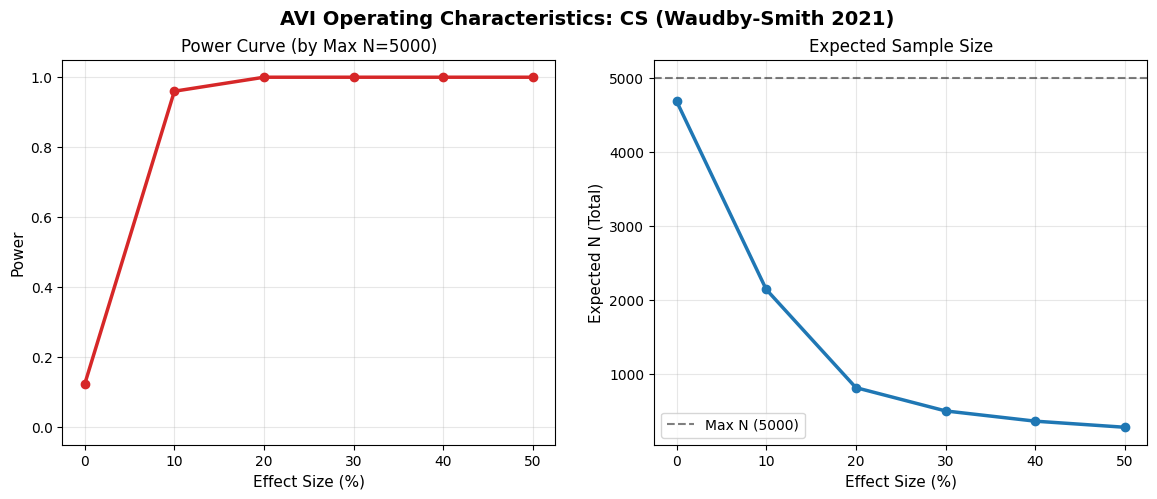

In [2]:
from earlysign.methods.AVI.reporting import visualize_avi_design

res = visualize_avi_design(protocol, effect_sizes=[0.0, 10.0, 20.0, 30.0, 40.0, 50.0])
display(res["summary"])
display(res["figure"])

## 2. Live Reporting of Intervals

As we update data, we can read out the current lower and upper bounds of the Confidence Sequence.

In this example, we compare two binomial arms and estimate the **Risk Difference** (difference in success rates) between the treatment and control arms:

$$\Delta = p_T - p_C$$

The "Effect Estimate" shown below is the observed difference $\hat{p}_T - \hat{p}_C$. The Confidence Sequence provides a time-uniform interval that contains the true difference $\Delta$ with 95% probability simultaneously across all sample sizes.

In [3]:
p_c, p_t = 0.10, 0.12
batch_size = 500

for i in range(1, 6):
    batch = [
        BinomialArmData(
            total=batch_size, success=np.random.binomial(batch_size, p_c), arm="control"
        ),
        BinomialArmData(
            total=batch_size,
            success=np.random.binomial(batch_size, p_t),
            arm="treatment",
        ),
    ]

    trial.update(batch)
    report = trial.report_progress()

    # AVI Progress reports include 'trajectory' (estimate) and 'boundary' (CI width)
    estimate = report["trajectory"]
    ci = report["boundary"]

    print(f"N={report['sample_n']}:")
    print(f"  Risk Difference (T-C) Estimate: {estimate:.4f}")
    print(f"  95% Confidence Sequence: [{estimate - ci:.4f}, {estimate + ci:.4f}]")

N=1000:
  Risk Difference (T-C) Estimate: 0.0000
  95% Confidence Sequence: [-0.0862, 0.0862]
N=2000:
  Risk Difference (T-C) Estimate: 0.0120
  95% Confidence Sequence: [-0.0412, 0.0652]
N=3000:
  Risk Difference (T-C) Estimate: 0.0133
  95% Confidence Sequence: [-0.0280, 0.0546]
N=4000:
  Risk Difference (T-C) Estimate: 0.0100
  95% Confidence Sequence: [-0.0249, 0.0449]
N=5000:
  Risk Difference (T-C) Estimate: 0.0116
  95% Confidence Sequence: [-0.0192, 0.0424]


## 3. Visualization

A proper Confidence Sequence visualization shows the interval shrinking as $N$ increases, while always containing the estimated parameter.

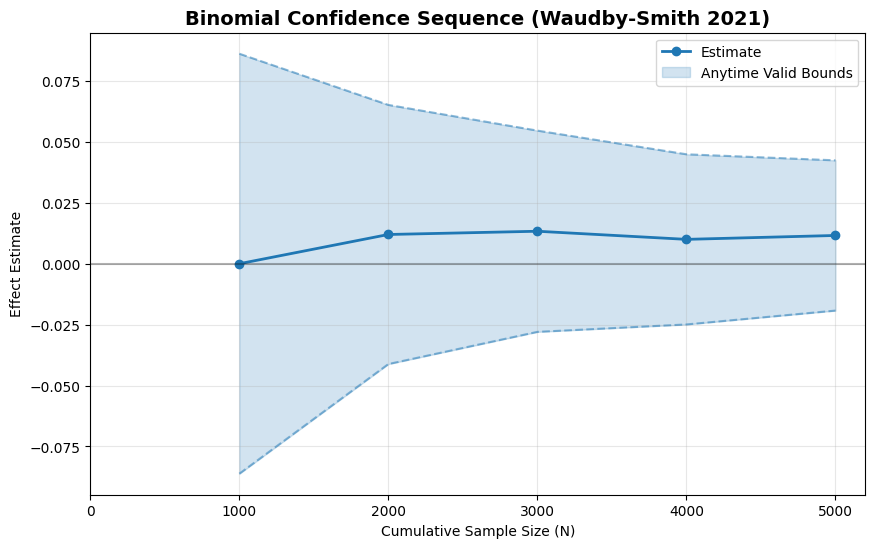

In [4]:
import matplotlib.pyplot as plt

from earlysign.methods.AVI.reporting import plot_avi_trajectory

# Reconstruct the history of the experiment from the ledger
plot_avi_trajectory(ledger, title="Binomial Confidence Sequence (Waudby-Smith 2021)")
plt.show()

## 4. Summary

- **CS**: Guaranteed coverage at all times, not just once.
- **Live UX**: Users can see the impact of their data in real-time without statistical invalidation.
- **Robustness**: Provides valid intervals regardless of when you decide to stop the trial.

This concludes our survey of sequential monitoring methods. In the next section, we will learn how to **Backtest** these designs on historical datasets.